Session 08 - Image Recognition

-[] Bag Of Words
tujuan: ngubah teks/dokumen, kata -> vektor/angka
cara: ngitungin frekuensi kemuncuan kata dalam dokumen

2. Bag of Visual Words
Translate terms yang ada di NLP -> Comvis
Dokument/teks = gambar
word = dict visual dict
histogram word = histogram visual word

Flow:
1. SIFT Descriptor buat dapetin fitur
2. Ngelakuin clustering pake K-Means (cluster1_sudutA, dll) -> tentuin centoroidnya juga
3. Nyocokin ulang descriptor hasil training dengan hasil visual dictionary, nantinya kita bakl bikin bentuk vektor
4. Testing dari hasil training
5. Bisa pake model classifiernya buat prediksi hal lain

-[] Classifier

In [1]:
# Import Modules

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.cluster.vq import * # dipake buat kmeans and vq (Vektor Quantization)
from sklearn.preprocessing import StandardScaler # Normalisasi Data
from sklearn.svm import LinearSVC # Classifier Model

In [8]:
# 1. Siapin Data Training
train_path = "dataset/Train/"
train_path_list = os.listdir(train_path)
labels = train_path_list

print(labels) # ['aeroplane', 'car', 'motorcycle']

image_list = []
image_class_id = [] # simpan index class 0, 1, 2 = ['aeroplane', 'car', 'motorcycle']

for index, class_path in enumerate(train_path_list):
    image_path_list = os.listdir(train_path + class_path)
    for image_path in image_path_list:
        image_list.append(os.path.join(train_path, class_path, image_path))
        image_class_id.append(index)

print(image_list)
print(image_class_id)

['car', 'motorcycle', 'aeroplane']
['dataset/Train/car/8.jpg', 'dataset/Train/car/9.png', 'dataset/Train/car/14.jpg', 'dataset/Train/car/15.jpg', 'dataset/Train/car/17.jpg', 'dataset/Train/car/16.png', 'dataset/Train/car/12.png', 'dataset/Train/car/13.png', 'dataset/Train/car/11.jpg', 'dataset/Train/car/10.jpg', 'dataset/Train/car/18.jpg', 'dataset/Train/car/4.jpg', 'dataset/Train/car/5.jpg', 'dataset/Train/car/7.jpg', 'dataset/Train/car/6.jpg', 'dataset/Train/car/2.png', 'dataset/Train/car/3.jpg', 'dataset/Train/car/1.png', 'dataset/Train/motorcycle/8.jpg', 'dataset/Train/motorcycle/9.jpg', 'dataset/Train/motorcycle/14.jpg', 'dataset/Train/motorcycle/15.jpg', 'dataset/Train/motorcycle/17.jpg', 'dataset/Train/motorcycle/16.jpg', 'dataset/Train/motorcycle/12.jpg', 'dataset/Train/motorcycle/13.png', 'dataset/Train/motorcycle/11.jpg', 'dataset/Train/motorcycle/10.jpg', 'dataset/Train/motorcycle/18.png', 'dataset/Train/motorcycle/4.png', 'dataset/Train/motorcycle/5.jpg', 'dataset/Train/mot

In [9]:
# 2. Extract Feature (SIFT)
sift = cv2.SIFT_create()
descriptor_list = []
for image_path in image_list:
    # Keypoints nya ga kepake
    _, descriptor = sift.detectAndCompute(cv2.imread(image_path), None)
    if descriptor is not None:
        descriptor_list.append(descriptor)

print(descriptor_list)

[array([[27., 92., 70., ...,  0.,  0.,  3.],
       [11., 22.,  2., ...,  0.,  0.,  0.],
       [16., 57., 97., ...,  0.,  0.,  0.],
       ...,
       [74., 10.,  1., ...,  0.,  0.,  0.],
       [ 3., 12., 49., ...,  0.,  0.,  0.],
       [ 0.,  0.,  1., ...,  0.,  0.,  0.]],
      shape=(271, 128), dtype=float32), array([[ 53.,  34.,   3., ...,   0.,   0.,   1.],
       [  0.,   0.,   0., ...,   0.,   0.,   1.],
       [  0.,   0.,   0., ...,   0.,   0.,   1.],
       ...,
       [  7.,  14.,  29., ...,   0.,   0.,   2.],
       [ 45.,  51.,   7., ...,   0.,   0.,   0.],
       [  9., 148., 110., ...,   0.,   0.,   0.]],
      shape=(812, 128), dtype=float32), array([[62.,  9.,  0., ..., 21., 86., 51.],
       [97., 27.,  0., ...,  0.,  0.,  1.],
       [ 4., 23., 28., ...,  0., 72., 39.],
       ...,
       [ 3.,  9., 25., ...,  0.,  0.,  0.],
       [14.,  2.,  1., ...,  0.,  0.,  3.],
       [ 0.,  4.,  8., ...,  0.,  0.,  4.]],
      shape=(292, 128), dtype=float32), array([[  6.

In [10]:
# 3. Buat Visual Dictionary (K-Means Clustering)

# 3.1 Stacking dari byk list array jadi 1 list aja

# sebelum stack:
# [ array shape (300, 128)
#   array shape (500, 128)
#   array shape (400, 128) ]

# setelah stack:
# [ array shape (1200, 128) ]

stacked_descriptor = descriptor_list[0] # descriptor pertama jadi base
for descriptor in descriptor_list[1:]: # slicing mulai dari secriptor kedua sampe terakhir
    stacked_descriptor = np.vstack((stacked_descriptor, descriptor))

stracked_descriptor = np.float32(stacked_descriptor) # K-Means butuh float32

# 3.2 K-Means Clustering
centroids, _ = kmeans(stacked_descriptor, 15, 25)
# 15 = Kelompok atau jumlah cluster
# 25 = Iterasi

In [11]:
# 4. Vector Quantization (Buat histogram visual words nya)

image_features = np.zeros((len(image_list), len(centroids)), "float32")
# Nampung histogram visual words untuk setiap gambar

for i in range(len(image_list)):
    words, _ = vq(descriptor_list[i], centroids)
    for w in words:
        image_features[i][w] += 1

In [12]:
# 5. Training Classifier

std_scaler = StandardScaler().fit(image_features)
image_features = std_scaler.transform(image_features)

# Contoh :
# histogram gambar A = [0, 2, 1, 0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0]
# histogram gambar B = [1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

svc = LinearSVC()
svc.fit(image_features, np.array(image_class_id))

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [13]:
# 6. Testing

test_path = 'dataset/Test/'
test_path_list = os.listdir(test_path)
image_list_test = []
for image in test_path_list:
    image_list_test.append(os.path.join(test_path, image))

descriptor_list_test = []
for image_path in image_list_test:
    _, descriptor = sift.detectAndCompute(cv2.imread(image_path), None)
    if descriptor is not None:
        descriptor_list_test.append(descriptor)

test_features = np.zeros((len(image_list_test), len(centroids)), "float32")
for i in range(len(image_list_test)):
    words, _ = vq(descriptor_list_test[i], centroids)
    for w in words:
        test_features[i][w] += 1

test_features = std_scaler.transform(test_features)
results = svc.predict(test_features)
print(results)

[2 1 0 0 1 2]


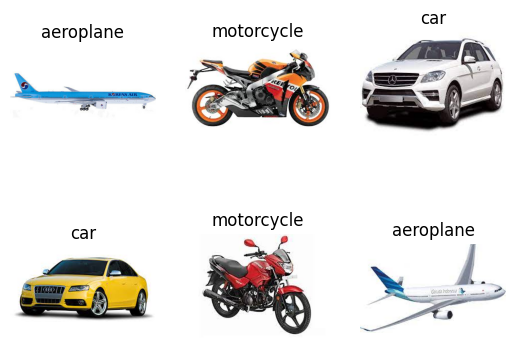

In [15]:
# 7. Plotting

for index, (class_id, image_path) in enumerate(zip(results, image_list_test)):
    plt.subplot(2, 3, index + 1)
    plt.title(labels[class_id])
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.axis("off")
plt.show()